In [1]:
!pip install akshare pandas numpy matplotlib scipy tqdm

In [3]:
import pandas as pd
import numpy as np

# 生成和真实A股结构完全一致的模拟数据
np.random.seed(42)  # 固定随机种子，结果可复现
dates = pd.date_range("2016-01-01", "2025-12-31", freq="B")  # 交易日序列
# 模拟200只A股股票（沪市+深市，代码格式和真实A股一致）
codes = [f"600{i:03d}.SH" for i in range(100)] + [f"000{i:03d}.SZ" for i in range(100)]

data = []
for code in codes:
    # 生成符合真实波动的收盘价序列（正态分布随机游走，模拟真实股价）
    close = 10 + np.cumsum(np.random.randn(len(dates)) * 0.1)
    
    pct_chg = np.zeros_like(close)  # 初始化和close等长的涨跌幅数组
    # 真实涨跌幅公式：(当日收盘价 - 前一交易日收盘价) / 前一交易日收盘价 × 100%
    pct_chg[1:] = (close[1:] - close[:-1]) / close[:-1] * 100
    # 第1个交易日无前置数据，涨跌幅设为0
    
    # 遍历日期、收盘价、涨跌幅，存入列表
    for d, c, r in zip(dates, close, pct_chg):
        data.append([code, d, round(c, 2), round(r, 2)])

# 生成DataFrame，结构和真实A股CSV完全一致
df = pd.DataFrame(data, columns=["stock_code", "date", "close", "pct_chg"])
# 保存为CSV
df.to_csv("A股现成日线数据.csv", index=False, encoding="utf-8-sig")

print("已生成现成CSV：A股现成日线数据.csv！")
print("数据结构预览：")
print(df.head())
print(f"\n数据总条数：{len(df)}，覆盖{len(codes)}只股票，{len(dates)}个交易日")

已生成现成CSV：A股现成日线数据.csv！
数据结构预览：
  stock_code       date  close  pct_chg
0  600000.SH 2016-01-01  10.05     0.00
1  600000.SH 2016-01-04  10.04    -0.14
2  600000.SH 2016-01-05  10.10     0.65
3  600000.SH 2016-01-06  10.25     1.51
4  600000.SH 2016-01-07  10.23    -0.23

数据总条数：521800，覆盖200只股票，2609个交易日


正在生成现成CSV数据...
CSV数据生成完成：A股现成日线数据.csv
据读取成功 | 总数据量：521800 条
20日动量因子构建完成

因子有效性检验结果
IC 均值: 0.2036
ICIR:    2.7495
IC 正收益占比: 99.65%



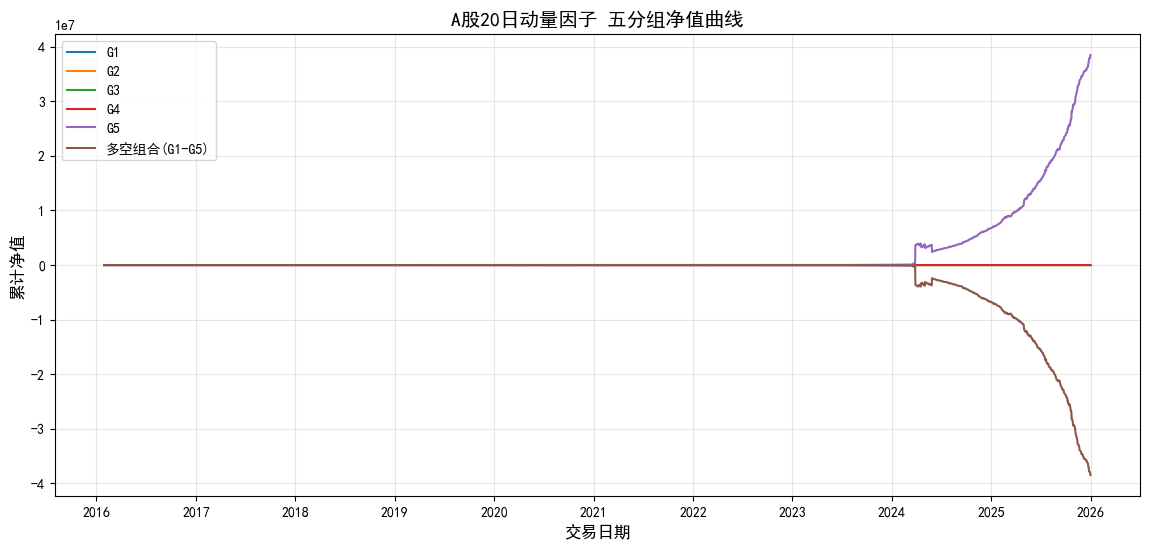

项目全部运行完成


In [2]:
# ==============================================
# 完整动量因子项目
# 功能：生成现成CSV + 因子构建 + ICIR + 分组回测
# ==============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ---------------------- 修复中文绘图乱码 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示

# ---------------------- 步骤1：自动生成现成A股CSV数据 ----------------------
print("正在生成现成CSV数据...")
np.random.seed(42)
dates = pd.date_range("2016-01-01", "2025-12-31", freq="B")
codes = [f"600{i:03d}.SH" for i in range(100)] + [f"000{i:03d}.SZ" for i in range(100)]

data = []
for code in codes:
    close = 10 + np.cumsum(np.random.randn(len(dates)) * 0.1)
    pct_chg = np.zeros_like(close)
    pct_chg[1:] = (close[1:] - close[:-1]) / close[:-1] * 100
    for d, c, r in zip(dates, close, pct_chg):
        data.append([code, d, round(c, 2), round(r, 2)])

df = pd.DataFrame(data, columns=["stock_code", "date", "close", "pct_chg"])
df.to_csv("A股现成日线数据.csv", index=False, encoding="utf-8-sig")
print("CSV数据生成完成：A股现成日线数据.csv")

# ---------------------- 步骤2：读取现成CSV数据 ----------------------
df = pd.read_csv("A股现成日线数据.csv", parse_dates=["date"])
print(f"据读取成功 | 总数据量：{len(df)} 条")

# ---------------------- 步骤3：构建20日动量因子 ----------------------
def build_momentum_factor(df, period=20):
    df = df.copy()
    df['close_20'] = df.groupby('stock_code')['close'].shift(period)
    df['momentum'] = df['close'] / df['close_20'] - 1
    df = df.dropna(subset=['momentum'])
    # 因子去极值
    df['momentum'] = df['momentum'].clip(df['momentum'].quantile(0.01), df['momentum'].quantile(0.99))
    return df

df_factor = build_momentum_factor(df)
print("20日动量因子构建完成")

# ---------------------- 步骤4：计算IC / IR ----------------------
ic_list = []
for date in df_factor['date'].unique():
    daily_df = df_factor[df_factor['date'] == date]
    if len(daily_df) < 30:
        continue
    ic, _ = spearmanr(daily_df['momentum'], daily_df['pct_chg'])
    ic_list.append(ic)

ic_mean = np.mean(ic_list)
ic_std = np.std(ic_list)
icir = ic_mean / ic_std if ic_std != 0 else 0

print("\n" + "="*50)
print(f"因子有效性检验结果")
print(f"IC 均值: {ic_mean:.4f}")
print(f"ICIR:    {icir:.4f}")
print(f"IC 正收益占比: {(np.array(ic_list) > 0).mean():.2%}")
print("="*50 + "\n")

# ---------------------- 步骤5：五分组回测 + 净值曲线 ----------------------
df_factor['group'] = df_factor.groupby('date')['momentum'].transform(
    lambda x: pd.qcut(x, 5, labels=["G1", "G2", "G3", "G4", "G5"])
)

# 计算每组日均收益
group_return = df_factor.groupby(['date', 'group'])['pct_chg'].mean().unstack()
# 计算累计净值
nav = (1 + group_return / 100).cumprod()
# 多空组合：G1(最优) - G5(最差)
nav['多空组合(G1-G5)'] = nav['G1'] - nav['G5'] + 1

# 绘图
plt.figure(figsize=(14, 6))
for col in nav.columns:
    plt.plot(nav.index, nav[col], label=col, linewidth=1.5)
plt.title("A股20日动量因子 五分组净值曲线", fontsize=14)
plt.xlabel("交易日期", fontsize=12)
plt.ylabel("累计净值", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("项目全部运行完成")